# Exercise 2: Statistical Visualization

## Name: Shaima Alqahtani

This exercise focuses on data visualization using `matplotlib` and `seaborn`. It covers the **M3-2: Statistical Visualization** learning outcomes. We will primarily use the Palmer Penguins dataset. Work through the sections in order.


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## A. Fundamentals of plotting

**1.** Explain the difference between a `figure` and an `axes` in `matplotlib`. (1-2 sentences)



*(Your answer)*


In [31]:
print('figure: is the overall window or canvas that contains everything in the plot (titles, axes, multiple subplots, etc.')
print('axes: is a single plotting area inside the figure where the actual data is drawn (with its own x- and y-axes).')

figure: is the overall window or canvas that contains everything in the plot (titles, axes, multiple subplots, etc.
axes: is a single plotting area inside the figure where the actual data is drawn (with its own x- and y-axes).



**2.** Name the three figure-level functions in `seaborn`.


In [32]:
#*(Your answer)*

print('sns.relplot(): for relational plots (scatter, line).') 
print('sns.displot(): for distribution plots (hist, kde, ecdf).') 
print('sns.catplot(): for categorical plots (bar, box, violin, etc.).') 

sns.relplot(): for relational plots (scatter, line).
sns.displot(): for distribution plots (hist, kde, ecdf).
sns.catplot(): for categorical plots (bar, box, violin, etc.).



**3.** Briefly explain the difference between a **Histogram** and a **Barplot**. Which one is used to show the distribution of numerical data, and which is used for categorical data?



*(Your answer)*



In [33]:
print('Histogram shows the distribution of a numerical variable by grouping values into bins and counting how many observations fall into each bin.')
print('Barplot shows values for categorical data, usually one bar per category (e.g., mean or count per category).')

Histogram shows the distribution of a numerical variable by grouping values into bins and counting how many observations fall into each bin.
Barplot shows values for categorical data, usually one bar per category (e.g., mean or count per category).


## B. Subplots and Grids

**1.** Using a seaborn **figure-level** function (like `sns.relplot` or `sns.displot`), create subplots using the `col` and `row` parameters. For example, plot `flipper_length_mm` vs `body_mass_g` across columns for `sex` and rows for `island`.

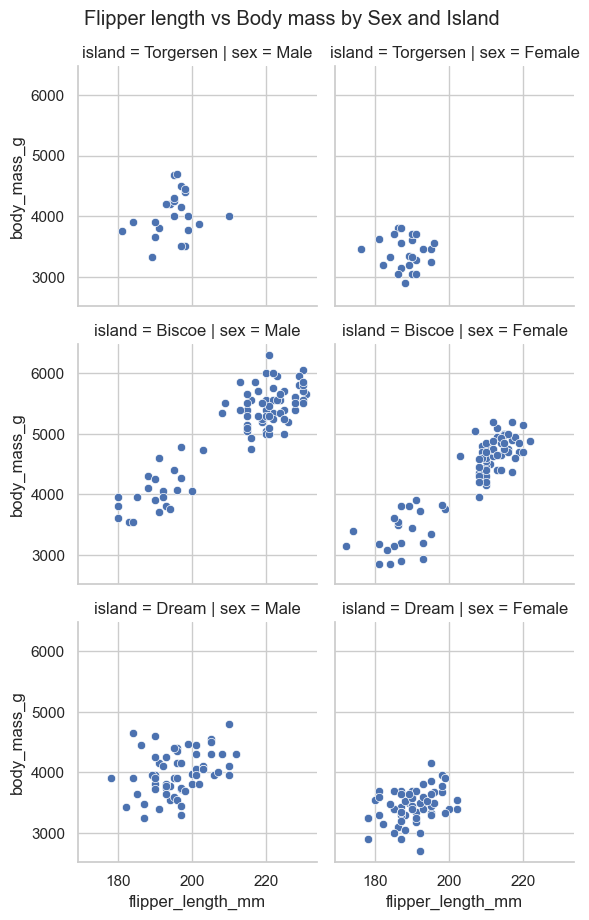

In [34]:
# YOUR CODE

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    col="sex",
    row="island",
    kind="scatter",
    height=3,
    aspect=1
)

g.fig.suptitle("Flipper length vs Body mass by Sex and Island", y=1.02)
plt.show()

**2.** Using **axes-level** functions, create a figure with subplots (e.g., 1 row and 2 columns) using `plt.subplots`. 
- Plot a scatterplot of `bill_length_mm` vs `bill_depth_mm` on the first axes (`ax1`).
- Plot a boxplot (or another axes-level plot of your choice) of `bill_length_mm` by `species` on the second axes (`ax2`).
- Make sure to use `sharey=True` (or `sharex=True`) where appropriate so the subplots are linked on the shared dimension.

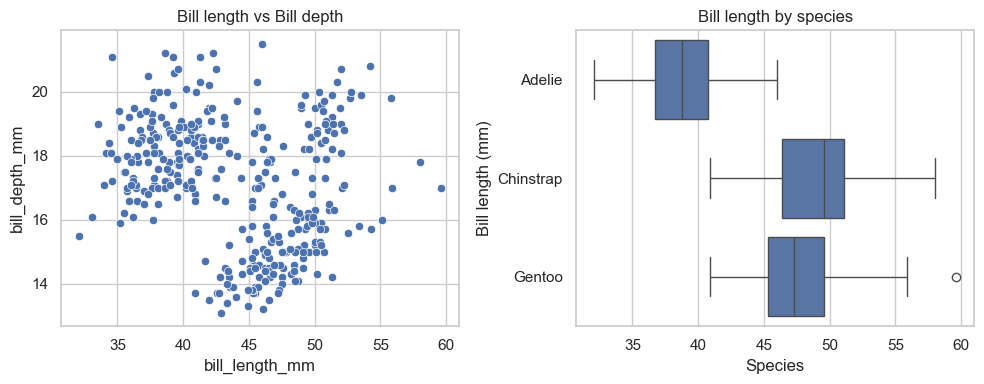

In [35]:
# YOUR CODE

import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

#ax1
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    ax=ax1
)
ax1.set_title("Bill length vs Bill depth")


#ax2
sns.boxplot(
    data=df,
    x="bill_length_mm",
    y="species",
    ax=ax2
)
ax2.set_title("Bill length by species")
ax2.set_xlabel("Species")
ax2.set_ylabel("Bill length (mm)")

plt.tight_layout()
plt.show()

## C. Visualizing Distributions

**1.** Write code to show a **box plot** of `flipper_length_mm` separated by `species`.

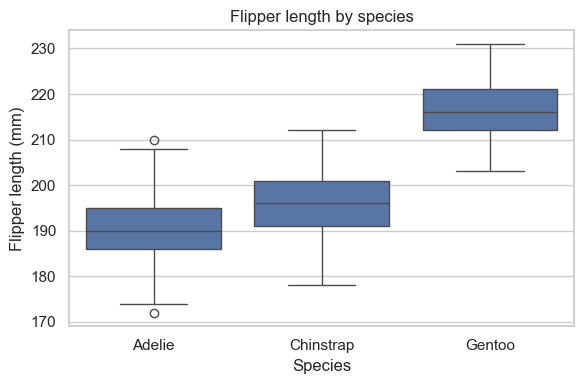

In [36]:
# YOUR CODE

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x="species",
    y="flipper_length_mm"
)
plt.title("Flipper length by species")
plt.xlabel("Species")
plt.ylabel("Flipper length (mm)")
plt.tight_layout()
plt.show()



**2.** Show two distributions on the same figure axes: plot the distribution of `body_mass_g` grouped by `sex` (e.g., using `sns.kdeplot`, or `sns.histplot` with overlapping transparent bins).



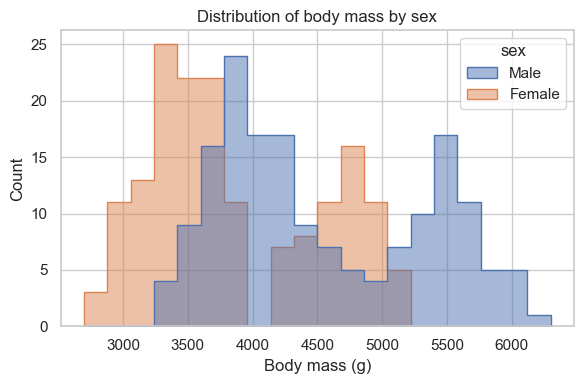

In [23]:
# YOUR CODE

plt.figure(figsize=(6, 4))

sns.histplot(
    data=df,
    x="body_mass_g",
    hue="sex",
    kde=False,
    bins=20,
    alpha=0.5,
    element="step"
)

plt.title("Distribution of body mass by sex")
plt.xlabel("Body mass (g)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



**3.** Plot the Empirical Cumulative Distribution Function (**ECDF**) for `body_mass_g`, split by `species`. Briefly interpret what the plot tells you about how the species compare in weight.



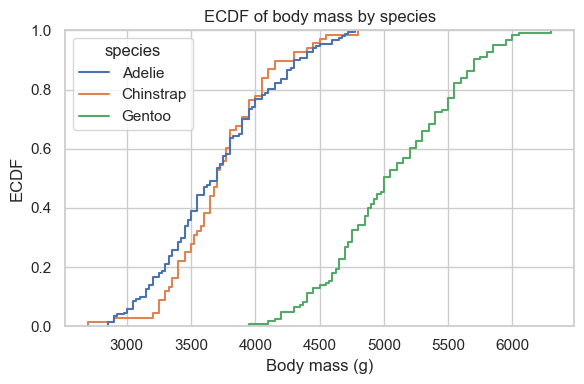

In [24]:
# YOUR CODE

plt.figure(figsize=(6, 4))

sns.ecdfplot(
    data=df,
    x="body_mass_g",
    hue="species"
)

plt.title("ECDF of body mass by species")
plt.xlabel("Body mass (g)")
plt.ylabel("ECDF")
plt.tight_layout()
plt.show()



*(Your interpretation here)*



**4.** Plot a **bi-variate histogram** using `sns.histplot` showing `bill_length_mm` on the x-axis and `bill_depth_mm` on the y-axis. What does the intensity mapping (the color blocks) represent?



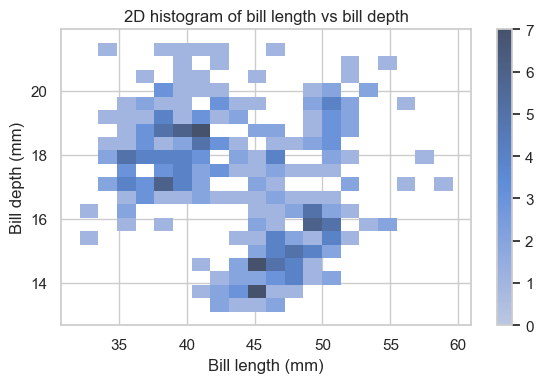

In [25]:
# YOUR CODE

plt.figure(figsize=(6, 4))

sns.histplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    bins=20,
    cbar=True
)

plt.title("2D histogram of bill length vs bill depth")
plt.xlabel("Bill length (mm)")
plt.ylabel("Bill depth (mm)")
plt.tight_layout()
plt.show()



*(Your interpretation here)*



## D. Categorical Data

**1.** Visualize numerical vs categorical relationships using `sns.catplot()`. Plot `bill_depth_mm` across different `island`s. Experiment with different categorical plot kinds (e.g., `kind='violin'` or `kind='swarm'`).

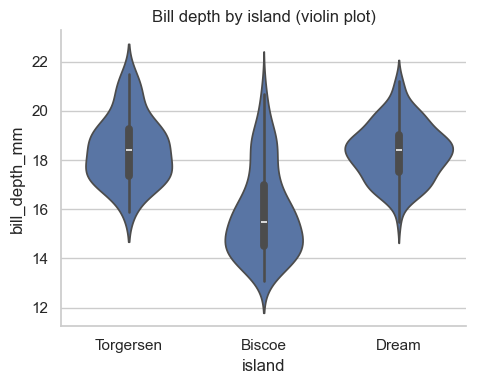

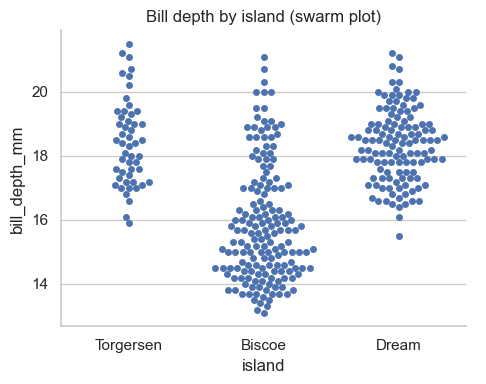

In [ ]:
# YOUR CODE

sns.set_theme(style="whitegrid")

sns.catplot(
    data=df,
    x="island",
    y="bill_depth_mm",
    kind="violin",
    height=4,
    aspect=1.2
)
plt.title("Bill depth by island (violin plot)")
plt.tight_layout()

sns.catplot(
    data=df,
    x="island",
    y="bill_depth_mm",
    kind="swarm",
    height=4,
    aspect=1.2
)
plt.title("Bill depth by island (swarm plot)")
plt.tight_layout()
plt.show()

**2.** Visualize multiple categorical variables in one plot. Show a count of penguins by `island`, and further separate the counts by `species` (using the `hue` parameter in a count plot or a similar approach).

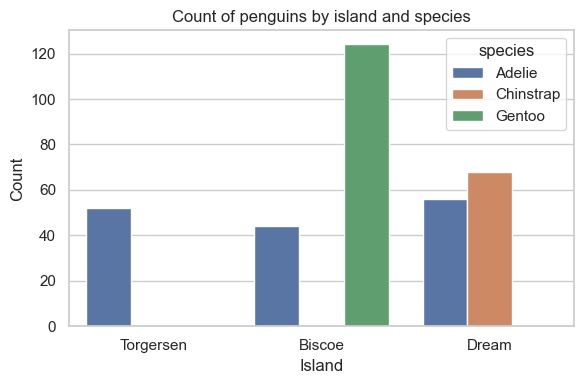

In [27]:
# YOUR CODE

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="island",
    hue="species"
)

plt.title("Count of penguins by island and species")
plt.xlabel("Island")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## E. Relational Plots and Aesthetics

**1.** Relate two numerical variables using a simple **scatter plot**: plot `bill_length_mm` vs `flipper_length_mm`.

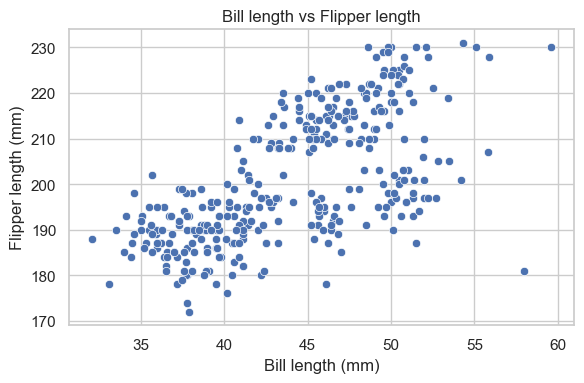

In [28]:
# YOUR CODE

plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm"
)

plt.title("Bill length vs Flipper length")
plt.xlabel("Bill length (mm)")
plt.ylabel("Flipper length (mm)")
plt.tight_layout()
plt.show()


**2.** Enhance the scatter plot from the previous step by using different **colors** (`hue`), **markers** (`style`), and **sizes** (`size`) based on other variables in the dataset. Make the plot visually distinct and ensure it is readable.

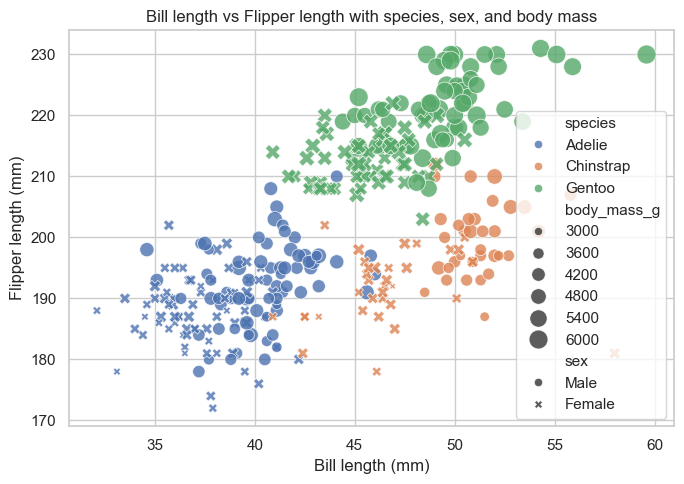

In [29]:
# YOUR CODE

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",      # color by species
    style="sex",        # marker style by sex
    size="body_mass_g", # marker size by body mass
    sizes=(20, 200),
    alpha=0.8
)

plt.title("Bill length vs Flipper length with species, sex, and body mass")
plt.xlabel("Bill length (mm)")
plt.ylabel("Flipper length (mm)")
plt.tight_layout()
plt.show()
